<a href="https://colab.research.google.com/github/Anshul-Kum/Anshul-Kum/blob/main/APM523_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

Reference deterministic solution:
x* = [1.75 0.75]
lambda* = [0.75 0.  ]
g(x*) = [ 0.   -0.75]

Baseline final x: [1.69696292 0.69696292]
Baseline final true constraints: [-0.10607415 -0.69696292]
Baseline final multipliers: [2.55432758 0.        ]

Persistence final x: [1.69539365 0.69539365]
Persistence final true constraints: [-0.10921271 -0.69539365]
Persistence final multipliers: [4.1902003 0.       ]


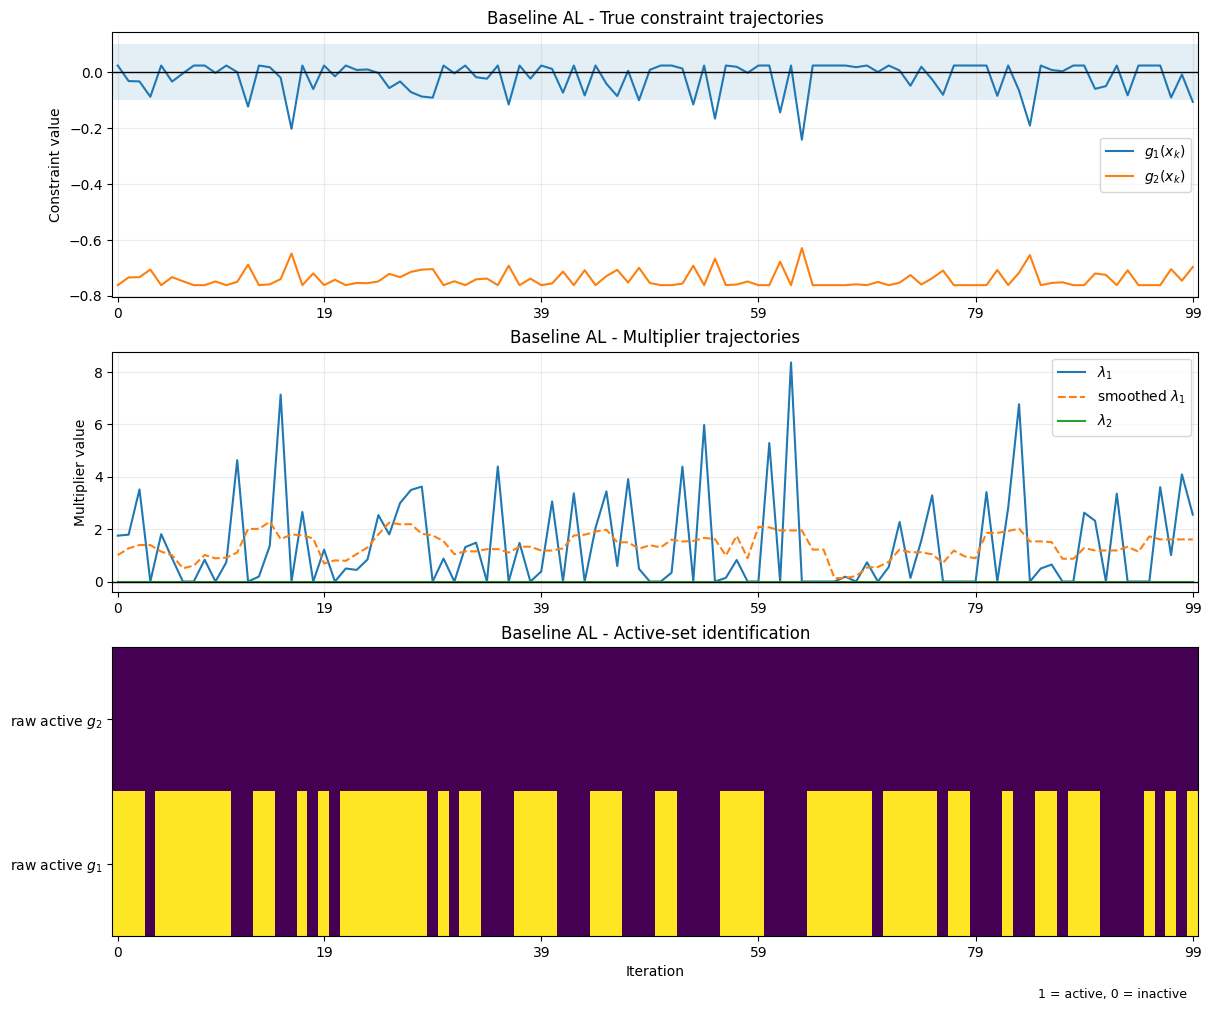

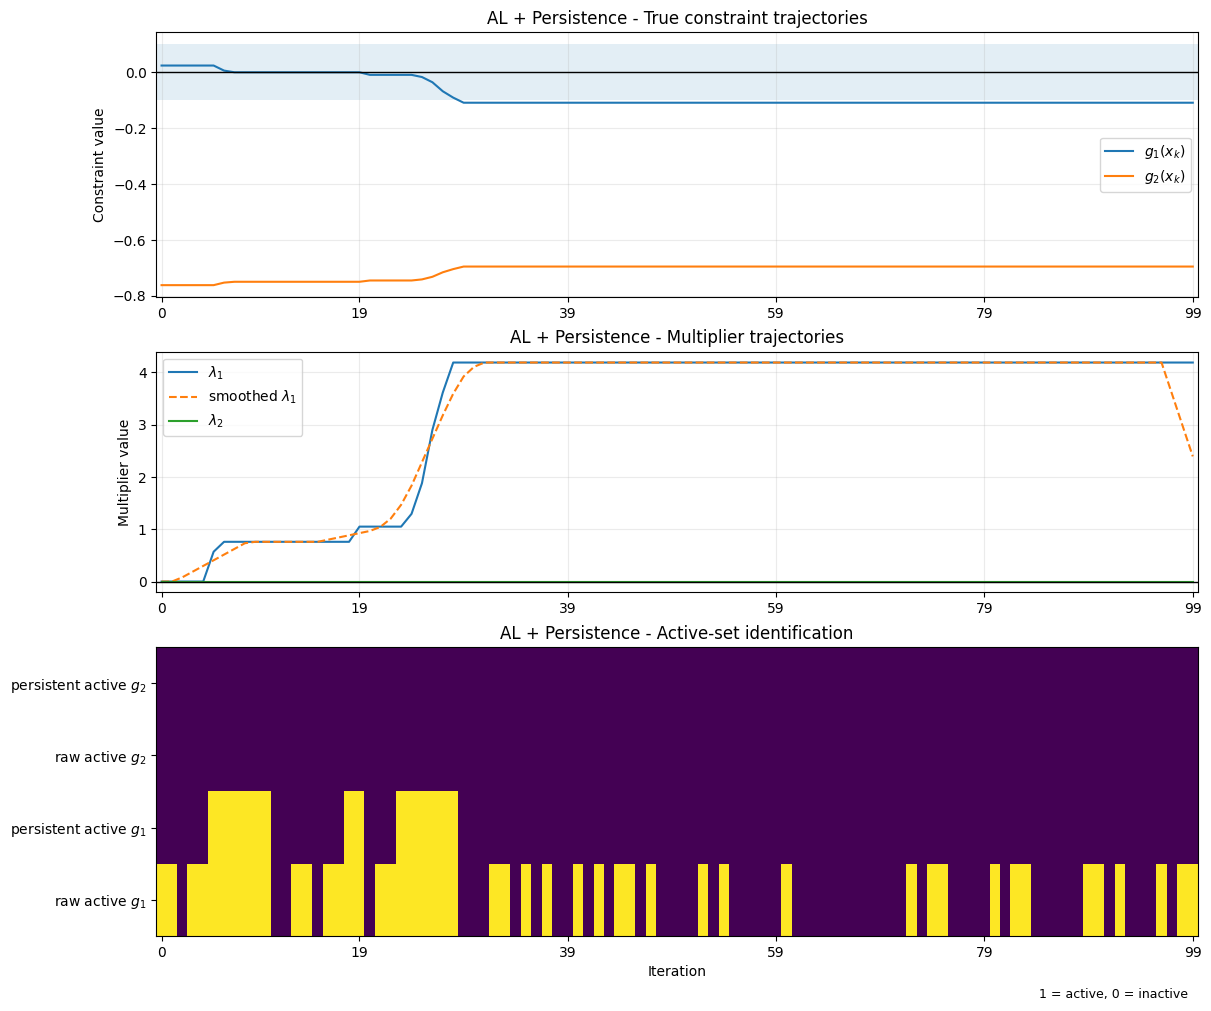

In [ ]:
# Quadratic objective:
# f(x) = 1/2 (x - c)^T Q (x - c)
c = np.array([2.0, 1.0])
Q = np.array([[2.0, 1.0],
              [1.0, 2.0]])

# Constraints:
# g1(x) = x1 + x2 - 2.5 <= 0
# g2(x) = x1 - 2x2 - 1.0 <= 0
def g_true(x):
    return np.array([
        x[0] + x[1] - 2.5,
        x[0] - 2.0 * x[1] - 1.0
    ])

# Jacobian of the constraints (constant because constraints are linear)
J = np.array([
    [1.0,  1.0],
    [1.0, -2.0]
])

sigma = 0.1
tau = 0.1
p = 3
mu = 30.0

max_outer_iters = 100
max_inner_iters = 20

x0 = np.array([0.0, 0.0])
lam0 = np.zeros(2)

x_star = np.array([1.75, 0.75])
lam_star = np.array([0.75, 0.0])


def f(x):
    d = x - c
    return 0.5 * d.T @ Q @ d


def grad_f(x):
    return Q @ (x - c)


def hess_f(x):
    return Q


def al_value(x, lam):
    gx = g_true(x)
    t = lam + mu * gx
    z = np.maximum(0.0, t)
    return f(x) + np.sum((z**2 - lam**2) / (2.0 * mu))


def al_grad_hess(x, lam):
    gx = g_true(x)
    t = lam + mu * gx
    z = np.maximum(0.0, t)

    # Gradient
    grad = grad_f(x) + J.T @ z

    # Hessian
    H = hess_f(x).copy()
    active = t > 0.0
    for i in range(2):
        if active[i]:
            H += mu * np.outer(J[i], J[i])

    # Small regularization for numerical safety
    H += 1e-12 * np.eye(2)
    return grad, H


def solve_inner_newton(x_start, lam, max_iters=max_inner_iters):
    x = x_start.copy()

    for _ in range(max_iters):
        grad, H = al_grad_hess(x, lam)

        try:
            step = -np.linalg.solve(H, grad)
        except np.linalg.LinAlgError:
            step = -grad

        if np.linalg.norm(step) < 1e-12:
            break

        # Backtracking line search on the AL merit function
        alpha = 1.0
        phi0 = al_value(x, lam)
        descent = grad @ step

        while True:
            x_trial = x + alpha * step
            phi_trial = al_value(x_trial, lam)

            if phi_trial <= phi0 + 1e-4 * alpha * descent:
                break

            alpha *= 0.5
            if alpha < 1e-12:
                break

        x_new = x + alpha * step

        if np.linalg.norm(x_new - x) < 1e-12:
            x = x_new
            break

        x = x_new

    return x

# Noise sequence
def generate_noise_sequence(seed=1):
    rng = np.random.default_rng(seed)
    return rng.normal(0.0, sigma, size=(max_outer_iters, 2))

# Baseline AL
def run_baseline(noise_seq):
    x = x0.copy()
    lam = lam0.copy()

    hist = {
        "x": [],
        "f": [],
        "g_true": [],
        "g_obs": [],
        "lam": [],
        "raw_active": []
    }

    for k in range(max_outer_iters):
        eps = noise_seq[k]

        # Inner solve uses the current AL model
        x_next = solve_inner_newton(x, lam)

        # Noisy observation at the new point
        g_obs_next = g_true(x_next) + eps

        raw_active = np.abs(g_obs_next) <= tau

        # Multiplier update with noisy constraints
        lam_next = np.maximum(0.0, lam + mu * g_obs_next)

        hist["x"].append(x_next.copy())
        hist["f"].append(f(x_next))
        hist["g_true"].append(g_true(x_next).copy())
        hist["g_obs"].append(g_obs_next.copy())
        hist["lam"].append(lam_next.copy())
        hist["raw_active"].append(raw_active.copy())

        x = x_next
        lam = lam_next

    for key in hist:
        hist[key] = np.array(hist[key])

    return hist

# AL + Persistence
def run_persistence(noise_seq):
    x = x0.copy()
    lam = lam0.copy()

    counters = np.zeros(2, dtype=int)
    obs_buffer = []

    hist = {
        "x": [],
        "f": [],
        "g_true": [],
        "g_obs": [],
        "lam": [],
        "raw_active": [],
        "persistent_active": [],
        "counters": []
    }

    for k in range(max_outer_iters):
        eps = noise_seq[k]

        x_next = solve_inner_newton(x, lam)

        g_obs_next = g_true(x_next) + eps
        obs_buffer.append(g_obs_next.copy())

        raw_active = np.abs(g_obs_next) <= tau

        # Persistence counters
        for i in range(2):
            if raw_active[i]:
                counters[i] += 1
            else:
                counters[i] = 0

        persistent_active = counters >= p

        if len(obs_buffer) >= p:
            recent_mean = np.mean(obs_buffer[-p:], axis=0)
        else:
            recent_mean = g_obs_next.copy()

        # only persistently active constraints are allowed to influence lambda
        g_used = np.zeros_like(g_obs_next)
        for i in range(2):
            if persistent_active[i]:
                g_used[i] = max(recent_mean[i], 0.0)

        lam_next = np.maximum(0.0, lam + mu * g_used)

        hist["x"].append(x_next.copy())
        hist["f"].append(f(x_next))
        hist["g_true"].append(g_true(x_next).copy())
        hist["g_obs"].append(g_obs_next.copy())
        hist["lam"].append(lam_next.copy())
        hist["raw_active"].append(raw_active.copy())
        hist["persistent_active"].append(persistent_active.copy())
        hist["counters"].append(counters.copy())

        x = x_next
        lam = lam_next

    for key in hist:
        hist[key] = np.array(hist[key])

    return hist

def rolling_mean(x, window=5):
    x = np.asarray(x)
    if len(x) < window:
        return x.copy()
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


def plot_method_summary(hist, title_prefix, tau=0.1):
    k = np.arange(len(hist["f"]))

    fig = plt.figure(figsize=(12, 10), constrained_layout=True)
    gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.0, 1.2])
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(k, hist["g_true"][:, 0], label=r"$g_1(x_k)$")
    ax1.plot(k, hist["g_true"][:, 1], label=r"$g_2(x_k)$")
    ax1.axhline(0.0, color="black", linewidth=1)
    ax1.axhspan(-tau, tau, alpha=0.12)
    ax1.set_title(f"{title_prefix} - True constraint trajectories")
    ax1.set_ylabel("Constraint value")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.25)
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    lam1 = hist["lam"][:, 0]
    lam2 = hist["lam"][:, 1]

    ax2.plot(k, lam1, label=r"$\lambda_1$")
    ax2.plot(k, rolling_mean(lam1, window=7), linestyle="--", label=r"smoothed $\lambda_1$")
    ax2.plot(k, lam2, label=r"$\lambda_2$")
    ax2.axhline(0.0, color="black", linewidth=1)
    ax2.set_title(f"{title_prefix} - Multiplier trajectories")
    ax2.set_ylabel("Multiplier value")
    ax2.legend(loc="best")
    ax2.grid(True, alpha=0.25)
    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

    if "persistent_active" in hist:
        data = np.vstack([
            hist["raw_active"][:, 0].astype(int),
            hist["persistent_active"][:, 0].astype(int),
            hist["raw_active"][:, 1].astype(int),
            hist["persistent_active"][:, 1].astype(int),
        ])
        row_labels = [
            "raw active $g_1$",
            "persistent active $g_1$",
            "raw active $g_2$",
            "persistent active $g_2$",
        ]
    else:
        data = np.vstack([
            hist["raw_active"][:, 0].astype(int),
            hist["raw_active"][:, 1].astype(int),
        ])
        row_labels = [
            "raw active $g_1$",
            "raw active $g_2$",
        ]

    ax3.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        vmin=0,
        vmax=1,
        cmap="viridis",
    )

    ax3.set_title(f"{title_prefix} - Active-set identification")
    ax3.set_xlabel("Iteration")
    ax3.set_yticks(np.arange(len(row_labels)))
    ax3.set_yticklabels(row_labels)

    tick_positions = np.linspace(0, len(k) - 1, 6, dtype=int)
    ax3.set_xticks(tick_positions)
    ax3.set_xticklabels([str(t) for t in tick_positions])

    ax3.text(
        0.99,
        -0.18,
        "1 = active, 0 = inactive",
        transform=ax3.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )

    plt.show()



if __name__ == "__main__":
    print("Reference deterministic solution:")
    print("x* =", x_star)
    print("lambda* =", lam_star)
    print("g(x*) =", g_true(x_star))
    print()

    noise_seq = generate_noise_sequence(seed=1)

    baseline_hist = run_baseline(noise_seq)
    persistence_hist = run_persistence(noise_seq)

    print("Baseline final x:", baseline_hist["x"][-1])
    print("Baseline final true constraints:", baseline_hist["g_true"][-1])
    print("Baseline final multipliers:", baseline_hist["lam"][-1])
    print()

    print("Persistence final x:", persistence_hist["x"][-1])
    print("Persistence final true constraints:", persistence_hist["g_true"][-1])
    print("Persistence final multipliers:", persistence_hist["lam"][-1])

    plot_method_summary(baseline_hist, "Baseline AL", tau=tau)
    plot_method_summary(persistence_hist, "AL + Persistence", tau=tau)

In [ ]:
# Logistic regression components
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss(w, X, y, rho=1e-3):
    """
    Regularized binary logistic loss.
    y should be in {0, 1}.
    """
    z = X @ w
    p = sigmoid(z)
    eps = 1e-12
    loss = -(1.0 / len(y)) * np.sum(
        y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
    )
    loss += 0.5 * rho * np.dot(w, w)
    return loss

def logistic_grad(w, X, y, rho=1e-3):
    z = X @ w
    p = sigmoid(z)
    grad = (X.T @ (p - y)) / len(y)
    grad += rho * w
    return grad

def g1(w):
    return w[0] + w[1] - 1.0   # <= 0

def g2(w):
    return w[0] - 2.0*w[1] - 0.5   # <= 0

# Deterministic constrained solve
def solve_deterministic_logistic(X, y, rho=1e-3, w0=None):
    """
    Returns an approximate deterministic constrained solution
    for logistic regression with linear inequality constraints.
    """
    n_features = X.shape[1]
    if w0 is None:
        w0 = np.zeros(n_features)

    # Objective and gradient
    def obj(w):
        return logistic_loss(w, X, y, rho=rho)

    def jac(w):
        return logistic_grad(w, X, y, rho=rho)

    constraints = [
        {"type": "ineq", "fun": lambda w: -g1(w)},
        {"type": "ineq", "fun": lambda w: -g2(w)}
    ]

    result = minimize(
        obj,
        w0,
        method="SLSQP",
        jac=jac,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": True}
    )

    return result

if __name__ == "__main__":
    # Synthetic example data
    np.random.seed(0)
    n = 50
    X = np.random.randn(n, 2)

    true_w = np.array([1.5, -0.8])
    logits = X @ true_w
    probs = sigmoid(logits)
    y = (probs > 0.5).astype(int)

    res = solve_deterministic_logistic(X, y, rho=1e-3)

    print("\nApproximate deterministic solution:")
    print("w* =", res.x)
    print("objective =", res.fun)
    print("success =", res.success)
    print("message =", res.message)
    print("g1(w*) =", g1(res.x))
    print("g2(w*) =", g2(res.x))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5420729658960255
            Iterations: 5
            Function evaluations: 5
            Gradient evaluations: 5

Approximate deterministic solution:
w* = [0.83333333 0.16666667]
objective = 0.5420729658960255
success = True
message = Optimization terminated successfully
g1(w*) = -3.3306690738754696e-16
g2(w*) = -2.7755575615628914e-16


Deterministic reference:
w* = [0.80654593 0.15327297]
objective = 0.5647540139268579
success = True
g(w*) = [-4.01811025e-02 -5.27800026e-13]

Baseline final w: [ 1.1056702 -0.2058426]
Baseline final true constraints: [-0.1001724  1.0173554]
Baseline final multipliers: [0.78350357 0.        ]

Persistence final w: [ 1.10530537 -0.21052457]
Persistence final true constraints: [-0.1052192   1.02635451]
Persistence final multipliers: [0.60160192 0.        ]


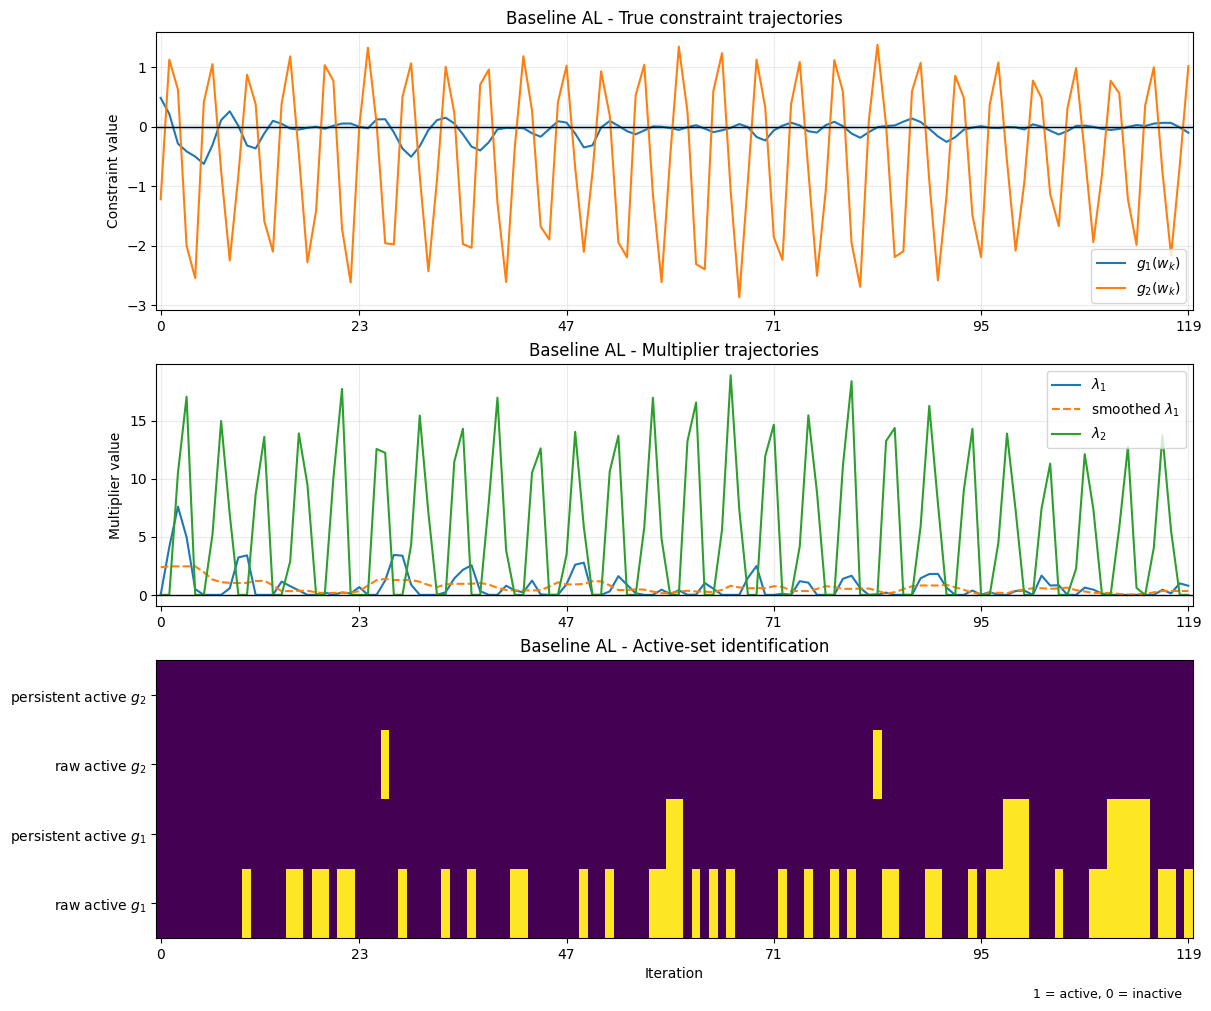

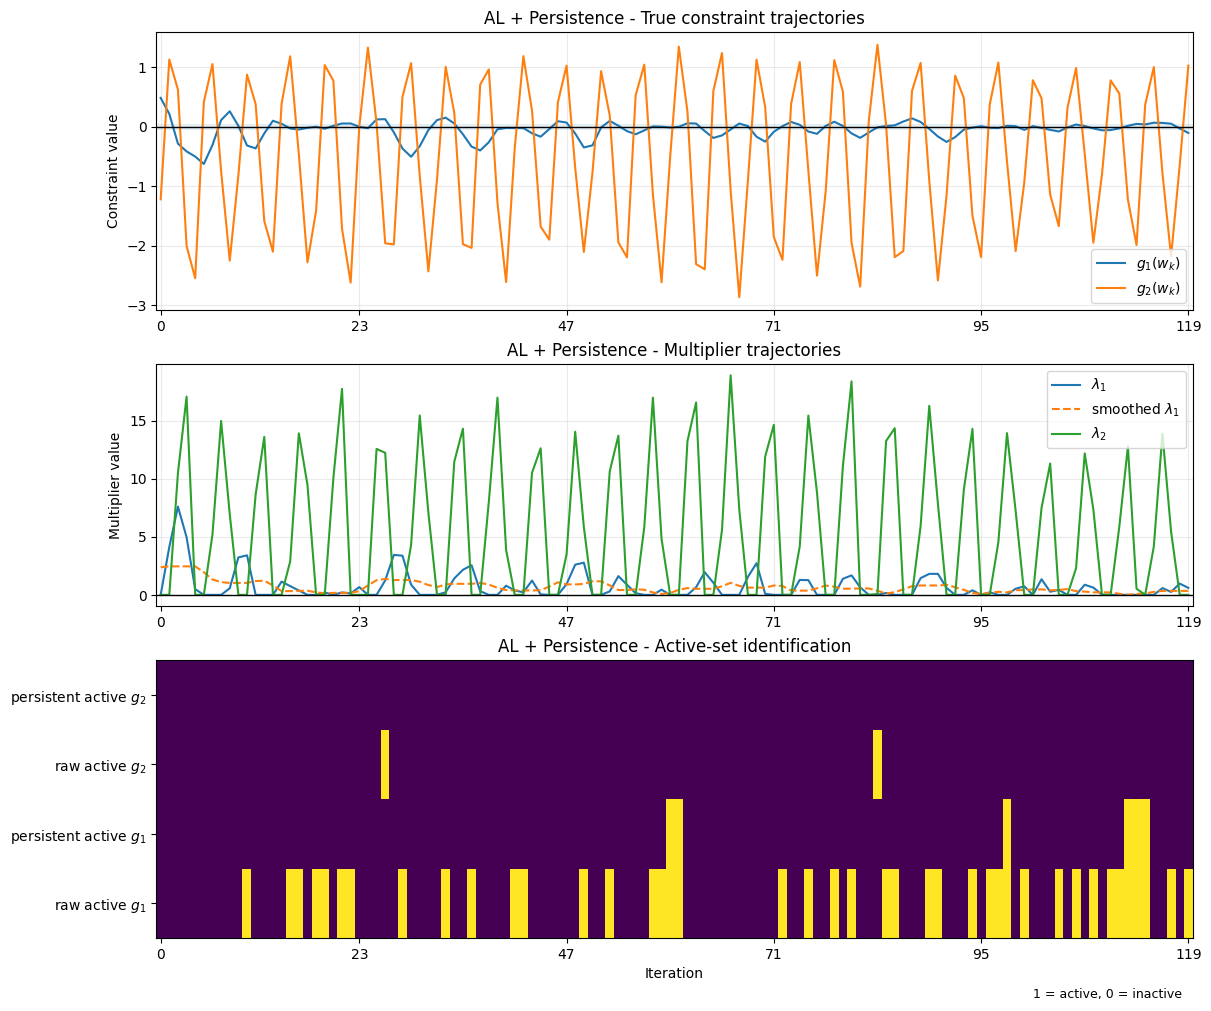

In [ ]:
def sigmoid(z):
    z = np.clip(z, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-z))

# Logistic regression model
def logistic_loss(w, X, y, rho=1e-3):
    z = X @ w
    p = sigmoid(z)
    eps = 1e-12
    loss = -(y * np.log(p + eps) + (1.0 - y) * np.log(1.0 - p + eps)).mean()
    loss += 0.5 * rho * np.dot(w, w)
    return loss


def logistic_grad(w, X, y, rho=1e-3):
    z = X @ w
    p = sigmoid(z)
    grad = (X.T @ (p - y)) / len(y)
    grad += rho * w
    return grad

# Linear inequality constraints
# g1(w) = w1 + w2 - 1 <= 0
# g2(w) = w1 - 2w2 - 0.5 <= 0
def g_true(w):
    return np.array([
        w[0] + w[1] - 1.0,
        w[0] - 2.0 * w[1] - 0.5
    ])

J = np.array([
    [1.0,  1.0],
    [1.0, -2.0]
])


def g_noisy(w, rng, sigma):
    return g_true(w) + rng.normal(0.0, sigma, size=2)

# Deterministic reference solve
def solve_deterministic_reference(X, y, rho=1e-3, w0=None):
    if w0 is None:
        w0 = np.zeros(X.shape[1])

    def obj(w):
        return logistic_loss(w, X, y, rho=rho)

    def jac(w):
        return logistic_grad(w, X, y, rho=rho)

    cons = [
        {"type": "ineq", "fun": lambda w: -g_true(w)[0]},
        {"type": "ineq", "fun": lambda w: -g_true(w)[1]},
    ]

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        jac=jac,
        constraints=cons,
        options={"maxiter": 1000, "ftol": 1e-12, "disp": False},
    )
    return res

# Stochastic AL + persistence
def run_stochastic_constrained_logistic(
    X,
    y,
    *,
    seed=1,
    sigma=0.05,
    rho=1e-3,
    mu=10.0,
    batch_size=16,
    outer_iters=120,
    inner_steps=25,
    lr=0.03,
    tau=0.05,
    patience=3,
    ema_beta=0.8,
    use_persistence=True,
):
    rng = np.random.default_rng(seed)
    n, d = X.shape

    w = np.zeros(d)
    lam = np.zeros(2)

    # Persistence
    counters = np.zeros(2, dtype=int)
    ema_g = np.zeros(2)

    # Adam
    m = np.zeros(d)
    v = np.zeros(d)
    beta1 = 0.9
    beta2 = 0.999
    adam_eps = 1e-8
    adam_t = 0

    hist = {
        "w": [],
        "loss": [],
        "g_true": [],
        "g_obs": [],
        "lam": [],
        "raw_active": [],
        "persistent_active": [],
        "counters": [],
    }

    for _ in range(outer_iters):
        g_obs = g_noisy(w, rng, sigma=sigma)
        ema_g = ema_beta * ema_g + (1.0 - ema_beta) * g_obs
        raw_active = np.abs(g_obs) <= tau

        # Persistence counters
        counters = np.where(raw_active, counters + 1, 0)
        persistent_active = counters >= patience

        # Stabilized constraint estimate
        if use_persistence:
            g_used = np.where(persistent_active, ema_g, g_obs)
        else:
            g_used = g_obs.copy()

        # Inner stochastic optimization steps
        for _ in range(inner_steps):
            idx = rng.choice(n, size=min(batch_size, n), replace=False)
            Xb = X[idx]
            yb = y[idx]

            # Minibatch logistic gradient
            grad = logistic_grad(w, Xb, yb, rho=rho)

            # AL-style constraint gradient
            grad += J.T @ (lam + mu * g_used)

            # Adam update
            adam_t += 1
            m = beta1 * m + (1.0 - beta1) * grad
            v = beta2 * v + (1.0 - beta2) * (grad * grad)
            m_hat = m / (1.0 - beta1 ** adam_t)
            v_hat = v / (1.0 - beta2 ** adam_t)

            w = w - lr * m_hat / (np.sqrt(v_hat) + adam_eps)

        # Dual update
        lam = np.maximum(0.0, lam + mu * g_used)

        # Logging
        hist["w"].append(w.copy())
        hist["loss"].append(logistic_loss(w, X, y, rho=rho))
        hist["g_true"].append(g_true(w).copy())
        hist["g_obs"].append(g_obs.copy())
        hist["lam"].append(lam.copy())
        hist["raw_active"].append(raw_active.copy())
        hist["persistent_active"].append(persistent_active.copy())
        hist["counters"].append(counters.copy())

    for key in hist:
        hist[key] = np.array(hist[key])

    return hist

# Example synthetic data
def make_synthetic_data(n=80, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, 2))
    true_w = np.array([1.0, -0.6])

    probs = sigmoid(X @ true_w)
    y = (probs > 0.5).astype(float)

    return X, y, true_w


def plot_history(base_hist, pers_hist):
    kb = np.arange(len(base_hist["loss"]))
    kp = np.arange(len(pers_hist["loss"]))

    plt.figure(figsize=(10, 4))
    plt.plot(kb, base_hist["g_true"][:, 0], label="Baseline g1")
    plt.plot(kb, base_hist["g_true"][:, 1], label="Baseline g2")
    plt.plot(kp, pers_hist["g_true"][:, 0], "--", label="Persistence g1")
    plt.plot(kp, pers_hist["g_true"][:, 1], "--", label="Persistence g2")
    plt.axhline(0.0, color="black", linewidth=1)
    plt.title("True constraints")
    plt.xlabel("Outer iteration")
    plt.ylabel("g(w)")
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.plot(kb, base_hist["lam"][:, 0], label="Baseline lambda1")
    plt.plot(kb, base_hist["lam"][:, 1], label="Baseline lambda2")
    plt.plot(kp, pers_hist["lam"][:, 0], "--", label="Persistence lambda1")
    plt.plot(kp, pers_hist["lam"][:, 1], "--", label="Persistence lambda2")
    plt.title("Multipliers")
    plt.xlabel("Outer iteration")
    plt.ylabel("lambda")
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.step(kb, base_hist["raw_active"][:, 0].astype(int), where="post", label="Baseline raw active g1")
    plt.step(kb, base_hist["raw_active"][:, 1].astype(int), where="post", label="Baseline raw active g2")
    plt.step(kp, pers_hist["persistent_active"][:, 0].astype(int), where="post", linestyle="--", label="Persistence active g1")
    plt.step(kp, pers_hist["persistent_active"][:, 1].astype(int), where="post", linestyle="--", label="Persistence active g2")
    plt.ylim(-0.1, 1.1)
    plt.title("Active-set tracking")
    plt.xlabel("Outer iteration")
    plt.ylabel("Active? (0/1)")
    plt.legend()
    plt.tight_layout()

    plt.show()

def rolling_mean(x, window=7):
  x = np.asarray(x)
  if len(x) < window:
      return x.copy()
  kernel = np.ones(window) / window
  return np.convolve(x, kernel, mode="same")


def plot_method_summary(hist, title_prefix, tau=0.05):
    k = np.arange(len(hist["loss"]))

    fig = plt.figure(figsize=(12, 10), constrained_layout=True)
    gs = fig.add_gridspec(3, 1, height_ratios=[1.15, 1.0, 1.15])
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(k, hist["g_true"][:, 0], label=r"$g_1(w_k)$")
    ax1.plot(k, hist["g_true"][:, 1], label=r"$g_2(w_k)$")
    ax1.axhline(0.0, color="black", linewidth=1)
    ax1.axhspan(-tau, tau, alpha=0.12)
    ax1.set_title(f"{title_prefix} - True constraint trajectories")
    ax1.set_ylabel("Constraint value")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.25)
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    lam1 = hist["lam"][:, 0]
    lam2 = hist["lam"][:, 1]

    ax2.plot(k, lam1, label=r"$\lambda_1$")
    ax2.plot(k, rolling_mean(lam1, window=7), linestyle="--", label=r"smoothed $\lambda_1$")
    ax2.plot(k, lam2, label=r"$\lambda_2$")
    ax2.axhline(0.0, color="black", linewidth=1)
    ax2.set_title(f"{title_prefix} - Multiplier trajectories")
    ax2.set_ylabel("Multiplier value")
    ax2.legend(loc="best")
    ax2.grid(True, alpha=0.25)
    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

    if "persistent_active" in hist:
        data = np.vstack([
            hist["raw_active"][:, 0].astype(int),
            hist["persistent_active"][:, 0].astype(int),
            hist["raw_active"][:, 1].astype(int),
            hist["persistent_active"][:, 1].astype(int),
        ])
        row_labels = [
            "raw active $g_1$",
            "persistent active $g_1$",
            "raw active $g_2$",
            "persistent active $g_2$",
        ]
    else:
        data = np.vstack([
            hist["raw_active"][:, 0].astype(int),
            hist["raw_active"][:, 1].astype(int),
        ])
        row_labels = [
            "raw active $g_1$",
            "raw active $g_2$",
        ]

    ax3.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        origin="lower",
        vmin=0,
        vmax=1,
        cmap="viridis",
    )

    ax3.set_title(f"{title_prefix} - Active-set identification")
    ax3.set_xlabel("Iteration")
    ax3.set_yticks(np.arange(len(row_labels)))
    ax3.set_yticklabels(row_labels)

    tick_positions = np.linspace(0, len(k) - 1, 6, dtype=int)
    ax3.set_xticks(tick_positions)
    ax3.set_xticklabels([str(t) for t in tick_positions])

    ax3.text(
        0.99,
        -0.18,
        "1 = active, 0 = inactive",
        transform=ax3.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )

    plt.show()


if __name__ == "__main__":
    X, y, true_w = make_synthetic_data(n=80, seed=0)

    ref = solve_deterministic_reference(X, y, rho=1e-3)
    print("Deterministic reference:")
    print("w* =", ref.x)
    print("objective =", ref.fun)
    print("success =", ref.success)
    print("g(w*) =", g_true(ref.x))
    print()

    base_hist = run_stochastic_constrained_logistic(
        X, y,
        seed=1,
        sigma=0.08,
        rho=1e-3,
        mu=10.0,
        batch_size=16,
        outer_iters=120,
        inner_steps=25,
        lr=0.03,
        tau=0.05,
        patience=3,
        ema_beta=0.8,
        use_persistence=False,
    )

    pers_hist = run_stochastic_constrained_logistic(
        X, y,
        seed=1,
        sigma=0.08,
        rho=1e-3,
        mu=10.0,
        batch_size=16,
        outer_iters=120,
        inner_steps=25,
        lr=0.03,
        tau=0.05,
        patience=3,
        ema_beta=0.8,
        use_persistence=True,
    )

    print("Baseline final w:", base_hist["w"][-1])
    print("Baseline final true constraints:", base_hist["g_true"][-1])
    print("Baseline final multipliers:", base_hist["lam"][-1])
    print()

    print("Persistence final w:", pers_hist["w"][-1])
    print("Persistence final true constraints:", pers_hist["g_true"][-1])
    print("Persistence final multipliers:", pers_hist["lam"][-1])

    plot_method_summary(base_hist, "Baseline AL", tau=0.05)
    plot_method_summary(pers_hist, "AL + Persistence", tau=0.05)